## Entropy

In [1]:
#p1=0.5 and p2=0.5 (impure split)
import math
entropy=-0.5*math.log2(0.5) -0.5*math.log2(0.5)
print("Entropy for 50%-50% case ==>", entropy)

Entropy for 50%-50% case ==> 1.0


In [2]:
# Pure split
entropy=-0.0001*math.log2(0.0001) -0.9999*math.log2(0.9999)
print("Entropy for 0%-100% case ==>", entropy)

Entropy for 0%-100% case ==> 0.0014730335283281598


In [3]:
import math
entropy=-0.45*math.log2(0.45) -0.55*math.log2(0.55)
print("Entropy for 45%-55% case ==>", entropy)

entropy=-0.05*math.log2(0.05) -0.95*math.log2(0.95)
print("Entropy for 5%-95% case ==>", entropy)

Entropy for 45%-55% case ==> 0.9927744539878083
Entropy for 5%-95% case ==> 0.28639695711595625


## Data Importing

In [2]:
#Import Data
import pandas as pd

Ecom_data = pd.read_csv("https://raw.githubusercontent.com/venkatareddykonasani/Datasets/master/Ecom_Cust_Relationship_Management/Ecom_Cust_Survey_v1.csv")

Ecom_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 11805 entries, 0 to 11804
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Cust_num              11805 non-null  int64
 1   Region                11805 non-null  int64
 2   Age                   11805 non-null  int64
 3   Order_Quantity        11805 non-null  int64
 4   Customer_Type         11805 non-null  str  
 5   Overall_Satisfaction  11805 non-null  str  
dtypes: int64(4), str(2)
memory usage: 553.5 KB


### Converting Non-Numeric data to Numerical

In [3]:
Ecom_data['Customer_Type_num'] = Ecom_data['Customer_Type'].map({'Prime': 1, 'Non_Prime': 0}).astype(int)
print(Ecom_data['Customer_Type'].value_counts())
print(Ecom_data['Customer_Type_num'].value_counts())

Customer_Type
Prime        6804
Non_Prime    5001
Name: count, dtype: int64
Customer_Type_num
1    6804
0    5001
Name: count, dtype: int64


In [4]:
Ecom_data['Overall_Satisfaction_num'] = Ecom_data['Overall_Satisfaction'].map( {'Dis Satisfied': 0, 'Satisfied': 1} ).astype(int)
print(Ecom_data['Overall_Satisfaction'].value_counts())
print(Ecom_data['Overall_Satisfaction_num'].value_counts())

Overall_Satisfaction
Dis Satisfied    6408
Satisfied        5397
Name: count, dtype: int64
Overall_Satisfaction_num
0    6408
1    5397
Name: count, dtype: int64


In [5]:
Ecom_data.columns

Index(['Cust_num', 'Region', 'Age', 'Order_Quantity', 'Customer_Type',
       'Overall_Satisfaction', 'Customer_Type_num',
       'Overall_Satisfaction_num'],
      dtype='str')

### Decision Tree Model Building

In [6]:
from sklearn import tree

features= ['Region', 'Age', 'Order_Quantity',  'Customer_Type_num']
print("Features",features)

X = Ecom_data[features]
print("X shape", X.shape)
y = Ecom_data['Overall_Satisfaction']
print("Y shape", y.shape)

Features ['Region', 'Age', 'Order_Quantity', 'Customer_Type_num']
X shape (11805, 4)
Y shape (11805,)


|--- Order_Quantity <= 40.50
|   |--- Age <= 29.50
|   |   |--- class: Satisfied
|   |--- Age >  29.50
|   |   |--- class: Dis Satisfied
|--- Order_Quantity >  40.50
|   |--- Age <= 20.50
|   |   |--- class: Satisfied
|   |--- Age >  20.50
|   |   |--- class: Satisfied



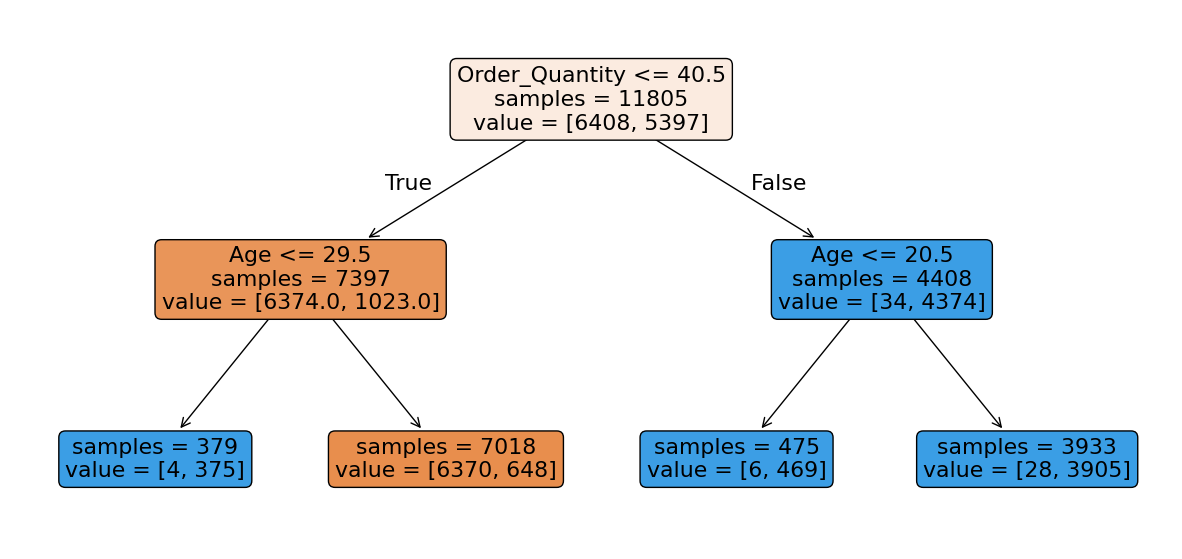

In [7]:
#Building Tree Model
DTree = tree.DecisionTreeClassifier(max_depth=2)
DTree.fit(X,y)

##Plotting the trees
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, export_text
plt.figure(figsize=(15,7))
plot_tree(DTree, filled=True,
                    rounded=True,
                    impurity=False,
                    feature_names = features)
print(export_text(DTree, feature_names = features))

### Tree/Model Validation

In [8]:
predict1 = DTree.predict(X)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y, predict1)
print("Confusion Matrix:\n", cm)
# Calculation of Accuracy using Confusion Matrix
total = sum(sum(cm))
accuracy = (cm[0,0] + cm[1,1])/total
print("Accuracy:", accuracy)
print("Accuracy in Percentage:", round(accuracy*100,1))


Confusion Matrix:
 [[6370   38]
 [ 648 4749]]
Accuracy: 0.9418890300720034
Accuracy in Percentage: 94.2


### The Problem of Overfitting

In [10]:
#Datasets: Diabetes
#Import both test and training data

train = pd.read_csv("https://raw.githubusercontent.com/venkatareddykonasani/Datasets/master/pima/diabetes_train.csv")
test = pd.read_csv("https://raw.githubusercontent.com/venkatareddykonasani/Datasets/master/pima/diabetes_test.csv")

print(train.sample(5))

     Count_Pregnancies  Glucose_level  BP  SkinThickness_index  Insulin_level  \
262                  6            103  66                    0              0   
195                  1             86  66                   52             65   
87                   1            109  38                   18            120   
95                   1            107  50                   19              0   
354                  0            139  62                   17            210   

      BMI  DiabetesPedigreeFunction  Age  Diabetes_outcome  
262  24.3                     0.249   29                 0  
195  41.3                     0.917   29                 0  
87   23.1                     0.407   26                 0  
95   28.3                     0.181   29                 0  
354  22.1                     0.207   21                 0  


In [11]:
from sklearn import tree

# Building Decision Tree Model and dividing data into train and test

#Defining Features and lables
features=['Count_Pregnancies', 'Glucose_level', 'BP', 'SkinThickness_index',
            'Insulin_level', 'BMI', 'DiabetesPedigreeFunction', 'Age']

X_train = train[features]
y_train = train['Diabetes_outcome']

#X_train

X_test = test[features]
y_test = test['Diabetes_outcome']

In [12]:
#training Tree Model
clf = tree.DecisionTreeClassifier()    #This'll by default will create large tree with many leaf nodes(considering max_depth=infinity) -> Overfitting
clf.fit(X_train,y_train)

predict1 = clf.predict(X_train)
predict2 = clf.predict(X_test)

# Notice the wide difference in accuracy between train and test data -> Overfitting
#On Train Data
cm1 = confusion_matrix(y_train,predict1)
total1 = sum(sum(cm1))
accuracy1 = round((cm1[0,0]+cm1[1,1])/total1,2)
print("Train Accuracy", accuracy1*100)  # accuracy in percentage

#On Test Data
cm2 = confusion_matrix(y_test,predict2)
total2 = sum(sum(cm2))
accuracy2 = round((cm2[0,0]+cm2[1,1])/total2,2)
print("Test Accuracy", accuracy2*100)

Train Accuracy 100.0
Test Accuracy 73.0


### Pruning

#### max_leaf_nodes Finetuning

In [13]:
#training Tree Model
# change 'max_leaf_nodes' to reduce overfitting and notice difference in accuracies
clf = tree.DecisionTreeClassifier(max_leaf_nodes = 16)
clf.fit(X_train,y_train)

predict1 = clf.predict(X_train)
predict2 = clf.predict(X_test)

#On Train Data
cm1 = confusion_matrix(y_train,predict1)
total1 = sum(sum(cm1))
accuracy1 = (cm1[0,0]+cm1[1,1])/total1
print("Train Accuracy", accuracy1)

#On Test Data
cm2 = confusion_matrix(y_test,predict2)
total2 = sum(sum(cm2))
accuracy2 = (cm2[0,0]+cm2[1,1])/total2
print("Test Accuracy", accuracy2)

# on having max_leaf_nodes=3000 => Accuracies are: 100 and 76% 
# on having max_leaf_nodes=1000 => Accuracies are: 100 and 77%
# on having max_leaf_nodes=500 => Accuracies are: 100 and 75%
# on having max_leaf_nodes=50 => Accuracies are: 91 and 81%
# on having max_leaf_nodes=16 => Accuracies are: 83 and 81% 

Train Accuracy 0.8338762214983714
Test Accuracy 0.8116883116883117
